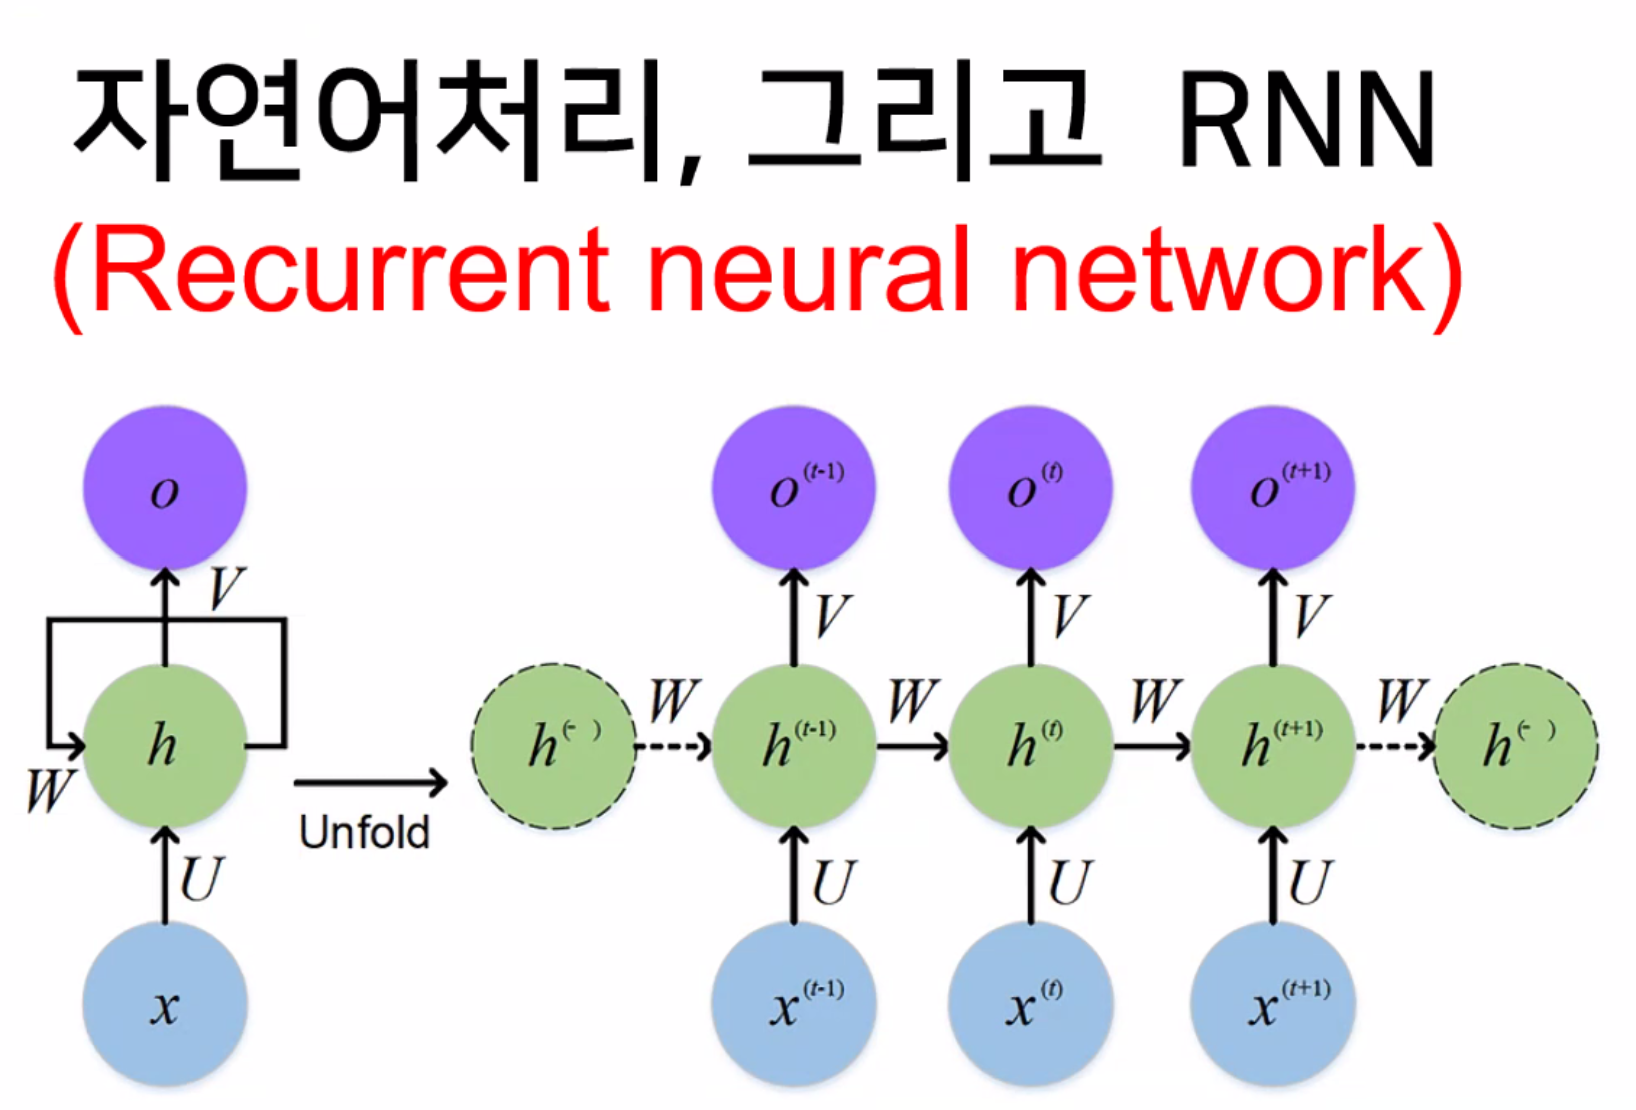

In [ ]:
# RNN : 순환신경망, 데이터들의 '순서'가 중요하다

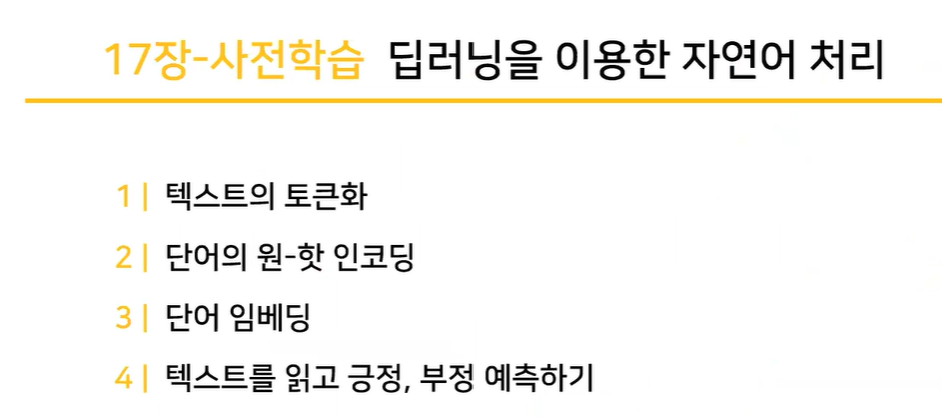

In [ ]:
# AI 모델이 처리하려면, 모든 문장을 숫자 '벡터'로 변환해야 한다 -> 텍스트 벡터화(Text Vectorization) 

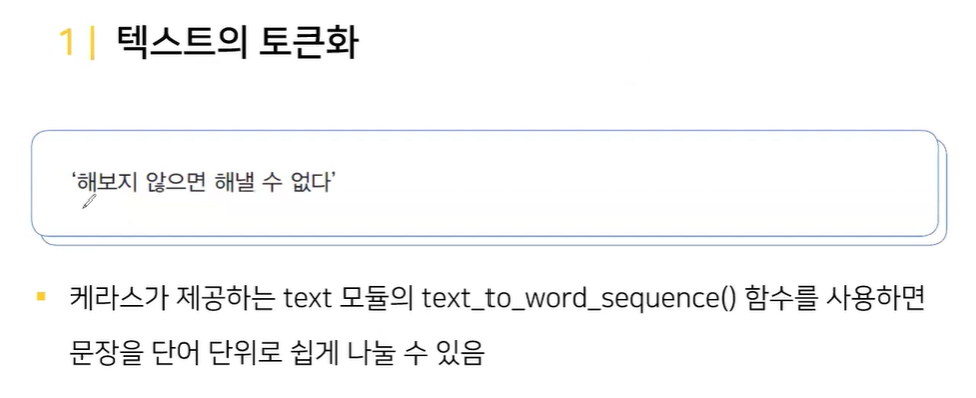

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

text = '해보지 않으면 해낼 수 없다'

# 토큰화
result = text_to_word_sequence(text)
print("\n원문:", text)
print("\n토큰화:", result)

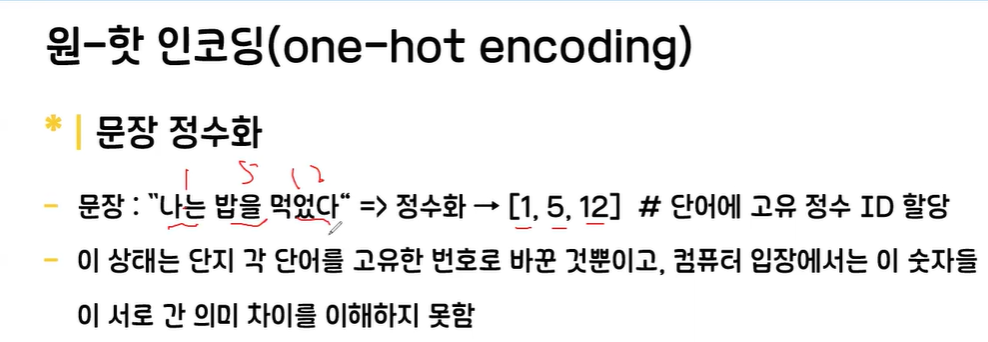

In [ ]:
# [1, 5, 12] 선형으로 착각될 수 있는 정수 말고
# 원-핫 인코딩
# [[1, 0, 0], -> 나는
#  [0, 1, 0], -> 밥을
#  [0, 0, 1]] -> 먹었다

In [ ]:
import numpy as np

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

token_index = {} # 딕셔너리

for sample in samples:
    print("sample", sample)

    for word in sample.replace('.', '').split(): # split() : default는 스페이스바
        if word not in token_index:
            token_index[word] = len(token_index) + 1 # token_index[word] -> Key, len(token_index) -> Value(index)
            # 인덱스 0은 사용하지 않는다

print(token_index)

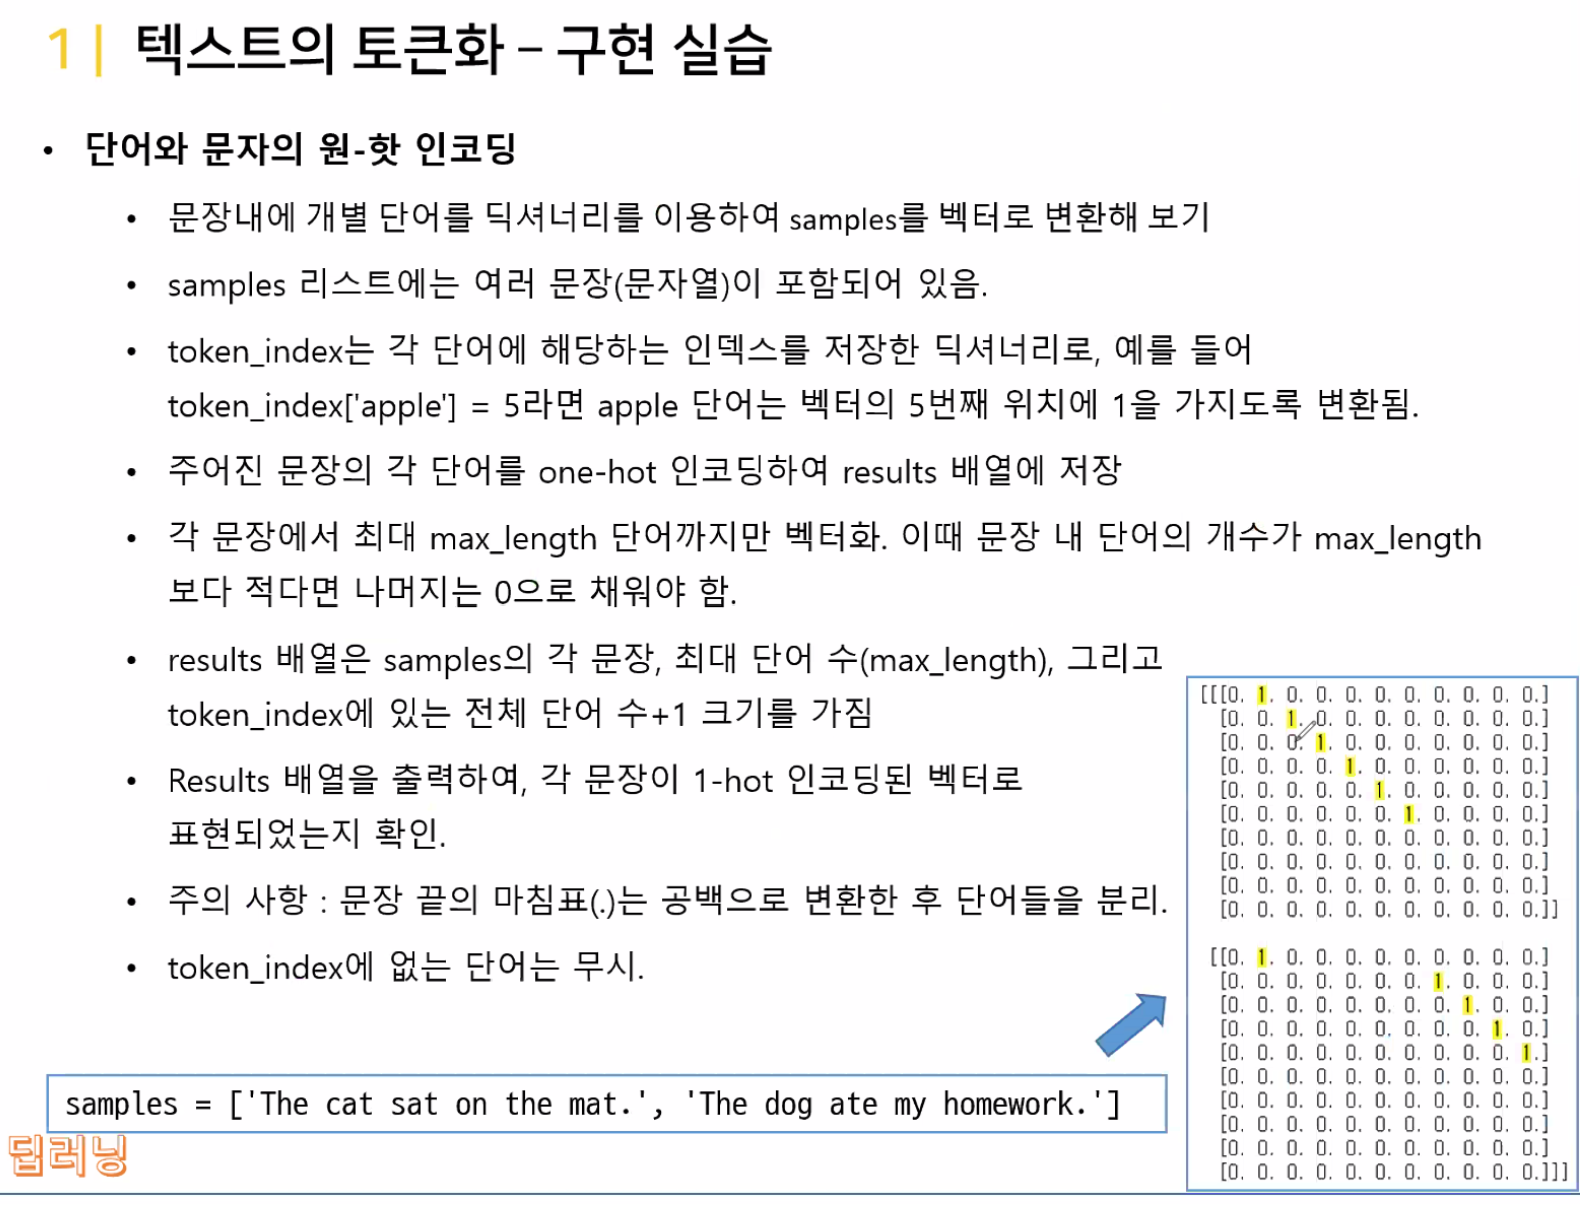

In [ ]:
import numpy as np

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

token_index = {} # 빈 딕셔너리 생성

for sample in samples:
    print("sample", sample)

    # split(), replace('.', '')
    for word in sample.replace('.', '').split():
        if word not in token_index:
            token_index[word] = len(token_index) + 1 # token_index[word] -> Key, len(token_index) -> Value(index)

# 문장 당, 최대 단어 갯수
max_length = 10

# np.zeros(파라미터 갯수) : np.zeros(깊이, 행, 열)의 차원 갯수 -> 3차원
# 깊이 -> 문장 갯수, 행 -> 단어의 최대 갯수, 열 -> 위쪽 word(key) : index(value) : 0은 안쓰는
results = np.zeros((len(samples), max_length, max(token_index.values())+1))
for i, sample in enumerate(samples):
    print("np.zeros sample:", sample)
    for j, word in list(enumerate(sample.replace('.', '').split()))[:max_length]:
        index = token_index.get(word)
        results[i, j, index] = 1

print(results)

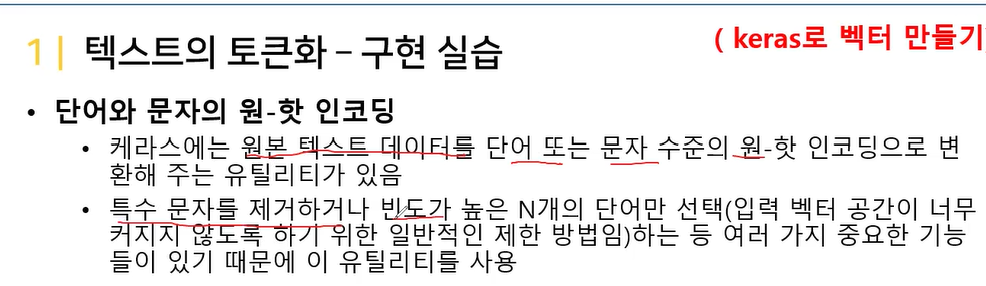

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer # 핵심!!
from tensorflow.keras.utils import to_categorical

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

# 가장 빈도가 높은 1,000개의 단어 선택하는 Tokenizer객체
tokenizer = Tokenizer(num_words=1000)

# 단어 인덱스 구축 : 가장 많이 나온 단어부터 1, 2, 3... 고유한 번호 부여
tokenizer.fit_on_texts(samples)
# print(tokenizer.word_index)

# 원-핫 인코딩1(texts_to_matrix)
one_hot_results = tokenizer.texts_to_matrix(samples, mode='binary') # 
print("one_hot_results:", one_hot_results.shape)

# 문자열을 정수 인덱스의 리스트로 변환
sequences = tokenizer.texts_to_sequences(samples)
# print(sequences)

# 원-핫 인코딩2(sequences_to_matrix) : 둘 중 하나 택 1
one_hot_results2 = tokenizer.sequences_to_matrix(sequences, mode='binary')
print("one_hot_results2:", one_hot_results2.shape)

# 단어 인덱스(위치정보) : tokenizer는 같은 단어가 나와도 딱 1번만 등록
word_index=tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

# 정수 인덱스의 리스트로 sequences를 원-핫 인코딩 배열로 만들기
x = to_categorical(sequences[0], num_classes=10)
print(x)
y = to_categorical(sequences[1], num_classes=10)
print(y)

In [ ]:
# 문장에서 중요한 단어는 '출현 빈도 수'로 결정된다

In [ ]:
import numpy
import tensorflow as tf

from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding

# 단어 빈도수
docs = ['먼저 텍스트의 각 단어를 나누어 토큰화 합니다.',
        '텍스트의 단어로 토큰화 해야 딥러닝에서 인식됩니다.',
        '토큰화 한 결과는 딥러닝에서 사용 할 수 있습니다.']

token = Tokenizer()

# 가장 많이 나온 단어부터 1, 2, 3... 고유한 방 번호 부여
token.fit_on_texts(docs)
# print(token.word_index)

#Tokenizer()의 word_counts함수는 순서를 기억하는 OrderedDict클래스를 사용합니다.
print("문장에서 단어 나온 횟수 카운트:", token.word_counts)

print("\n문장 카운트:", token.document_count)
print("\n단어가 몇개의 문장에 포함되어 있는가:\n", token.word_docs)
print("\n단어에 매겨진 인덱스 값(방 번호):\n", token.word_index)

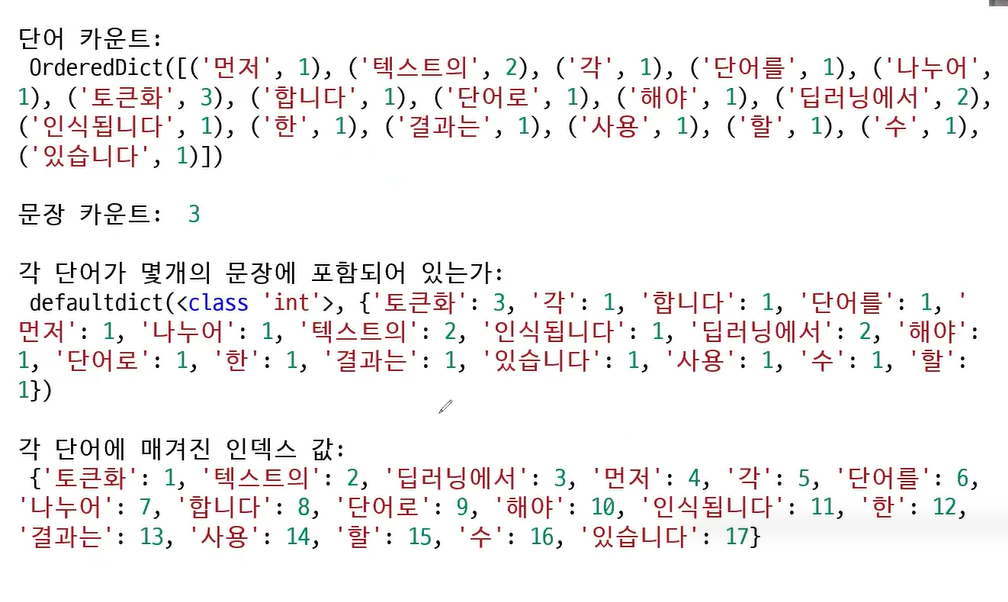

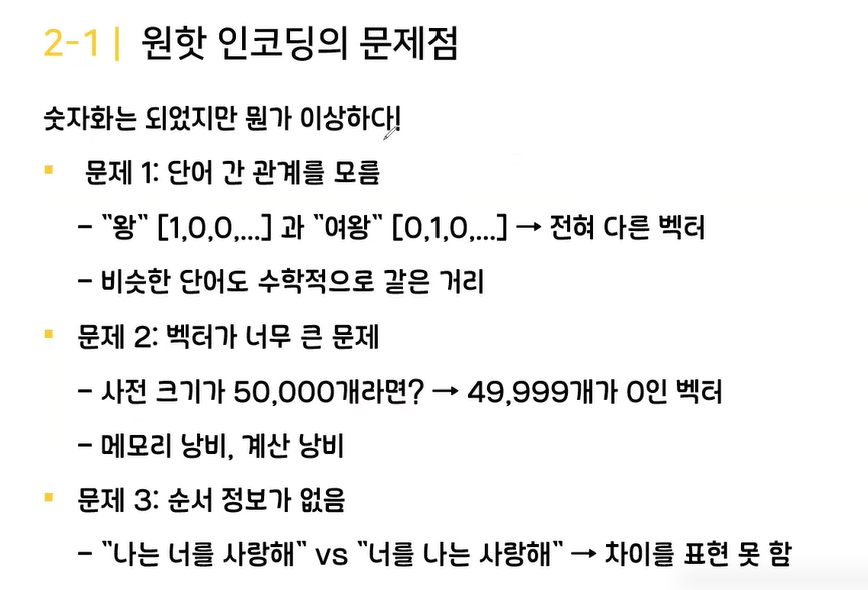

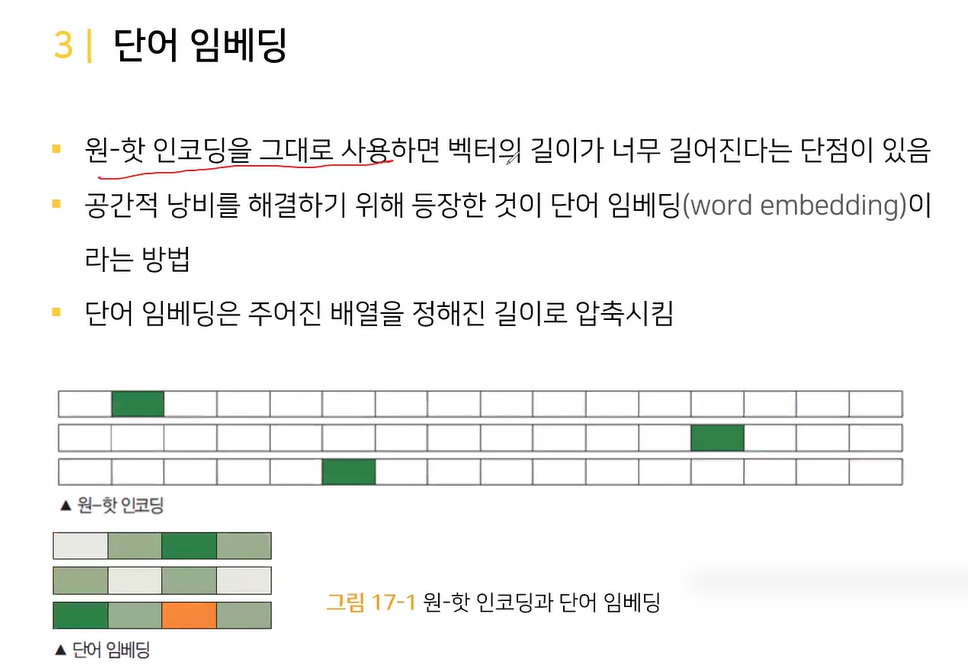

In [ ]:
# 단어 임베딩은 주어진 배열을 정해진 길이로 압축시킨다
# -> 정해진 칸에, 단어가 가진 성질의 점수를 채워넣기 때문에(실수값으로)

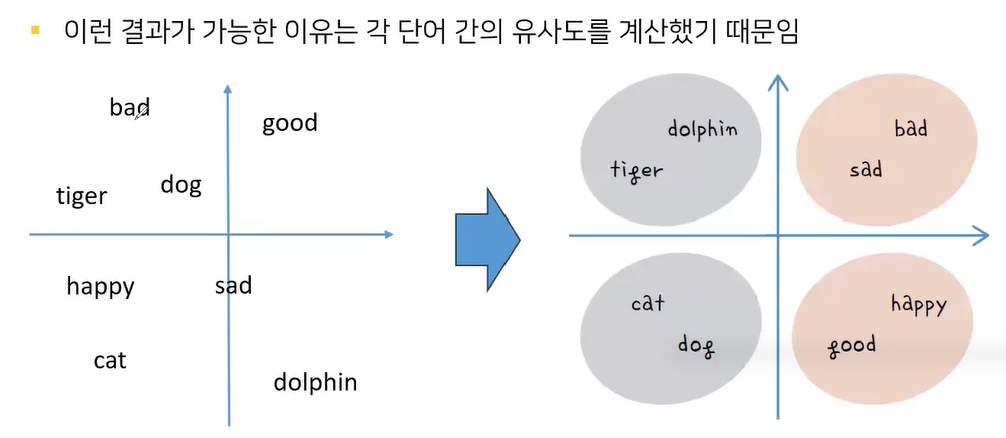

In [ ]:
# 단어 간 유사도 계산 -> 오차역전파
# keras -> Embedding() 함수

In [ ]:
# Embedding(16, 4, input_lenth=2) 함수는 최소 2개의 매개변수 필요 (16, 4) -> (입력, 출력)
# 16 : 입력되는 총 단어 수
# 4 : 출력되는 벡터 크기
# input_lenth(추가 시) : 단어를 매번 얼마나 입력할지 지정 

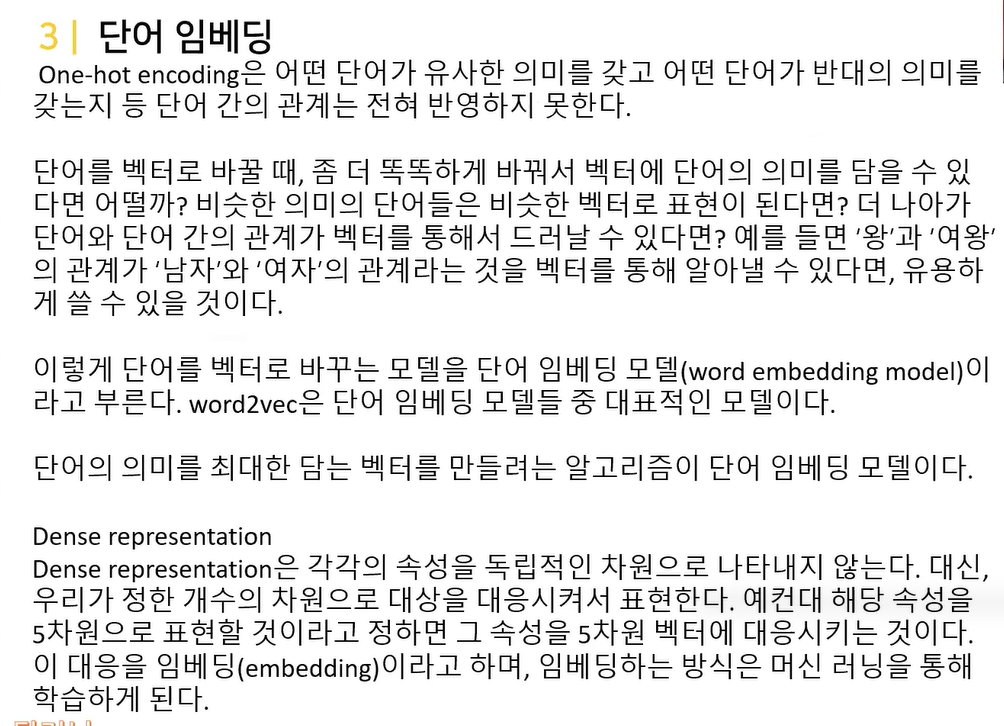

In [ ]:
# 단어 임베딩 예시 코드
# 어떻게 이루어지는지, 간단한 확인 정도만

In [ ]:
import numpy as np
import warnings

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

warnings.filterwarnings('ignore')

sentences = [
    "왕은 나라를 다스리는 남자입니다.",
    "여왕은 나라를 다스리는 여자입니다.",
    "남자가 왕이 되었습니다.",
    "여자가 여왕이 되었습니다.",
    "왕과 여왕은 함께 궁전에서 살고 있습니다.",
    "남자와 여자가 파티에 참석했습니다.",
    "왕은 충성스러운 신하들을 거느립니다.",
    "여왕은 아름다운 드레스를 입고 있었습니다.",
    "남자가 여왕의 조언자가 되었습니다.",
    "여자가 왕의 자리를 노리고 있습니다."
]

tokenizer = Tokenizer(
    # 조사 붙은 단어까지 구분되도록 최소 필터만 적용
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

sequences = tokenizer.texts_to_sequences(sentences)
# print("fit_on_texts(전) sequences :", sequences)
tokenizer.fit_on_texts(sentences) # 문장 속 단어 출현 빈도 확인 후, 빈도에 따라 방 번호(인덱스) 배치
sequences = tokenizer.texts_to_sequences(sentences)
# print("fit_on_texts(후) sequences :", sequences)

word_index = tokenizer.word_index
print("단어 목록 : ", word_index)

# 패딩 : 문장의 길이가 동일하도록 '0'으로 채워주는 작업
padded = pad_sequences(sequences, padding='post') # pre : 앞에 0 채우기, post : 뒤에 0 채우기
print("패딩된 시퀀스 : ", padded) # x_train

# +1 : padding 작업을 위해 남겨두는 index 0을 위해
vocab_size = len(word_index) + 1
embedding_dim = 8
max_len = padded.shape[1]

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim)) # (입력, 출력)
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy')

# 더미 라벨로 임베딩만 학습
model.fit(padded, np.ones((len(sentences), 1)), epochs=10, verbose=2) # np.ones() 대신, 실제 정답(y_train)이 있어야 한다

embedding_matrix = model.layers[0].get_weights()[0]

# '왕'이라는 단어가 포함되면 출력
for word in word_index: 
    if "왕" in word: # contains개념
        print(f"\n*단어 '{word}'의 임베딩 벡터 :")
        print(embedding_matrix[word_index[word]])

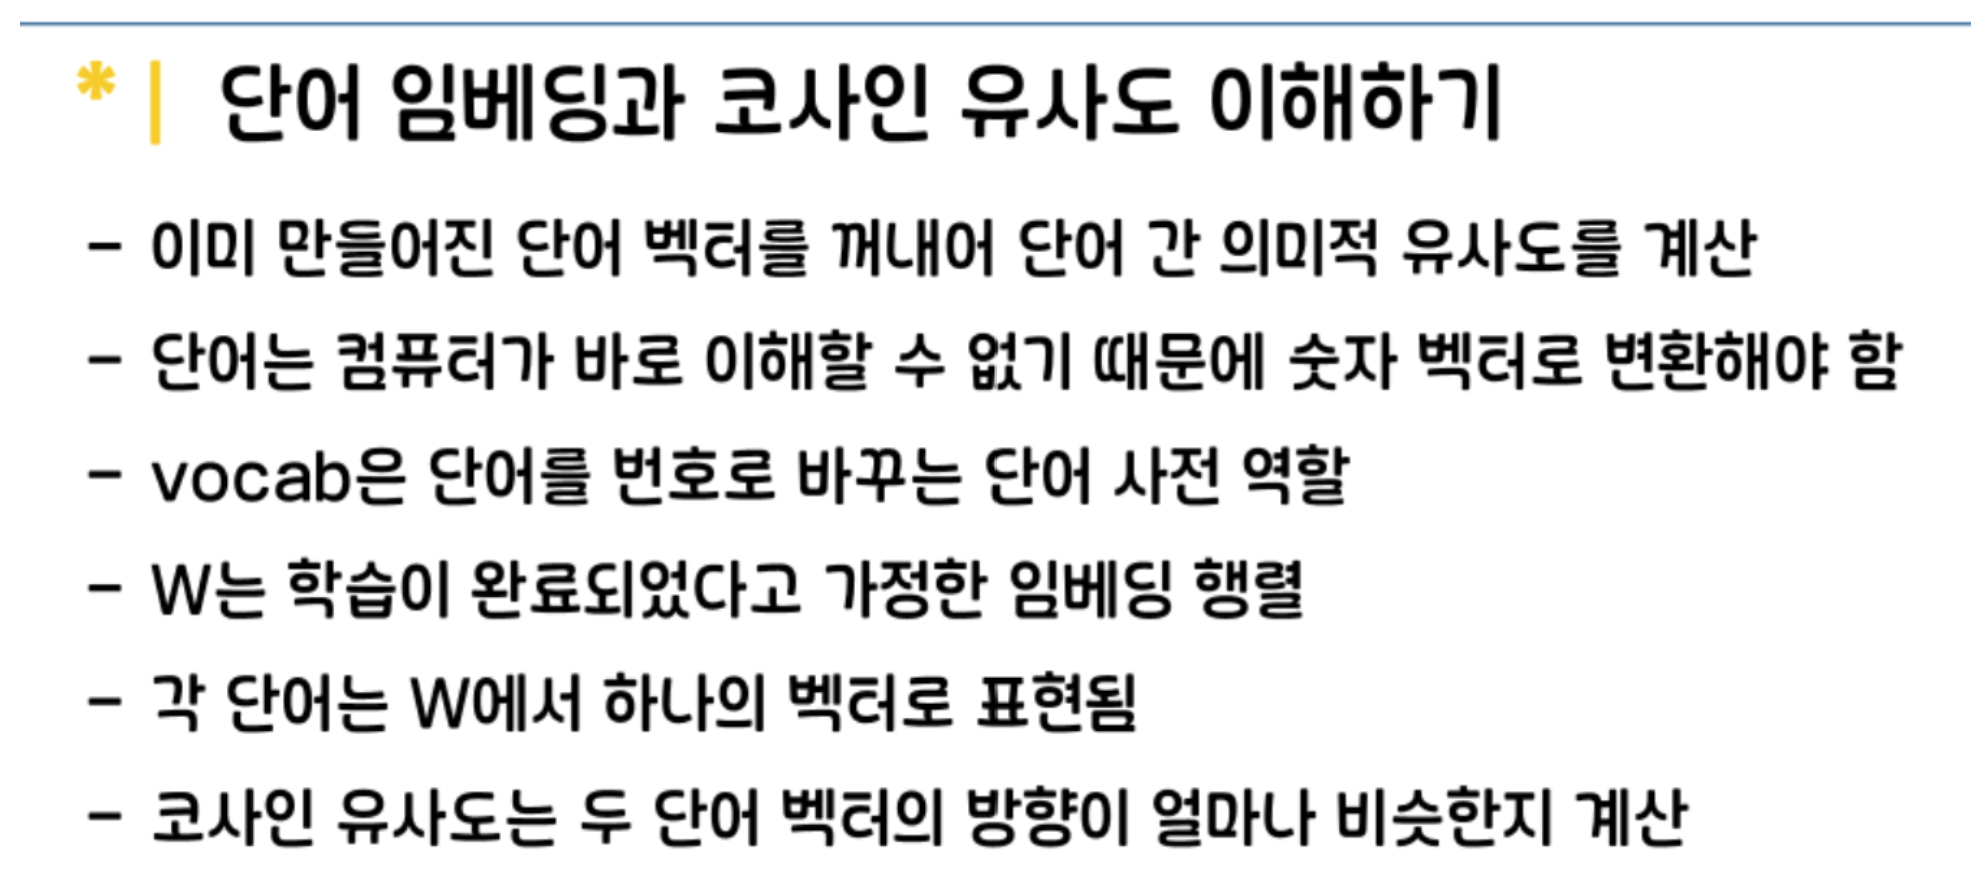

In [ ]:
# -------------------------------------------------------------
# 1. 임베딩 실습에 사용할 문장
# -------------------------------------------------------------
# 실제 자연어 문장에서는 "왕은", "왕국을", "여자는"처럼 조사가 붙어 있음
# 여기서는 형태소 분석을 하지 않으므로, vocab과 일치하도록 단어를 분리하여 사용함
corpus = [
    "왕 왕국 다스린다",
    "여왕 왕국 다스린다",
    "남자 여자 사람",
    "왕 남자 이다",
    "여왕 여자 이다",
]

# -------------------------------------------------------------
# 2. 단어 사전: 단어(key) -> 번호(value)
# -------------------------------------------------------------
vocab = {
    "왕": 0,
    "여왕": 1,
    "왕국": 2,
    "남자": 3,
    "여자": 4,
    "사람": 5,
    "다스린다": 6,
    "이다": 7
}

vocab_size = len(vocab) # 입력 : 8
embed_dim = 3           # 출력 : 3

# -------------------------------------------------------------
# 3. 임베딩 행렬 W
# -------------------------------------------------------------
# 실제 딥러닝 학습에서는 W가 처음에는 임의의 값으로 초기화되고,
# 문장 데이터를 학습하면서 단어의 의미와 문맥 관계가 반영되도록 수정됨
# 이번 실습에서는 학습 과정은 생략하고,
# 이미 학습이 완료되었다고 가정한 임베딩 행렬을 직접 정의함
# W의 각 행은 하나의 단어에 대응하는 3차원 임베딩 벡터임
# 예 : W[0]은 "왕"의 임베딩 벡터
# 지금 이 W는 학습이 완료되었다고 '가정'한 데이터
W = [
    # dim0   dim1   dim2
    [0.82,  0.41,  0.12],  # 왕
    [0.79, -0.38,  0.11],  # 여왕
    [0.10,  0.05,  0.95],  # 왕국
    [0.70,  0.40, -0.15],  # 남자
    [0.68, -0.42, -0.13],  # 여자
    [0.60,  0.01, -0.05],  # 사람
    [0.05,  0.08,  0.88],  # 다스린다
    [0.02,  0.03,  0.12],  # 이다
]

# -------------------------------------------------------------
# 4. 단어를 임베딩 벡터로 변환하는 함수
# -------------------------------------------------------------
def embedding(word):
    index = vocab[word] # word : key, index : value
    return W[index]     # 해당 번호(index)의 임베딩 벡터 반환

# "왕"의 임베딩 벡터 확인
print("왕의 임베딩 벡터:", embedding("왕"))

# -------------------------------------------------------------
# 5. 코사인 유사도 함수
# -------------------------------------------------------------
# 두 벡터의 방향이 얼마나 비슷한지 계산하는 방법
#  1에 가까움 : 방향이 매우 비슷함
#  0에 가까움 : 관련성이 낮음
# -1에 가까움 : 반대 방향임
def cosine_sim(a, b):
    # 두 벡터의 내적 계산
    dot = sum(x * y for x, y in zip(a, b))

    # 각 벡터의 길이 계산
    norm_a = sum(x ** 2 for x in a) ** 0.5
    norm_b = sum(x ** 2 for x in b) ** 0.5

    # 코사인 유사도 반환
    return dot/(norm_a * norm_b)

# -------------------------------------------------------------
# 6. 단어 간 코사인 유사도 계산
# -------------------------------------------------------------
print("왕 - 여왕 : ", round(cosine_sim(embedding("왕"), embedding("여왕")), 2))
print("왕 - 남자 : ", round(cosine_sim(embedding("왕"), embedding("남자")), 2))
print("왕 - 왕국 : ", round(cosine_sim(embedding("왕"), embedding("왕국")), 2))
print("남자 - 여자 : ", round(cosine_sim(embedding("남자"), embedding("여자")), 2))

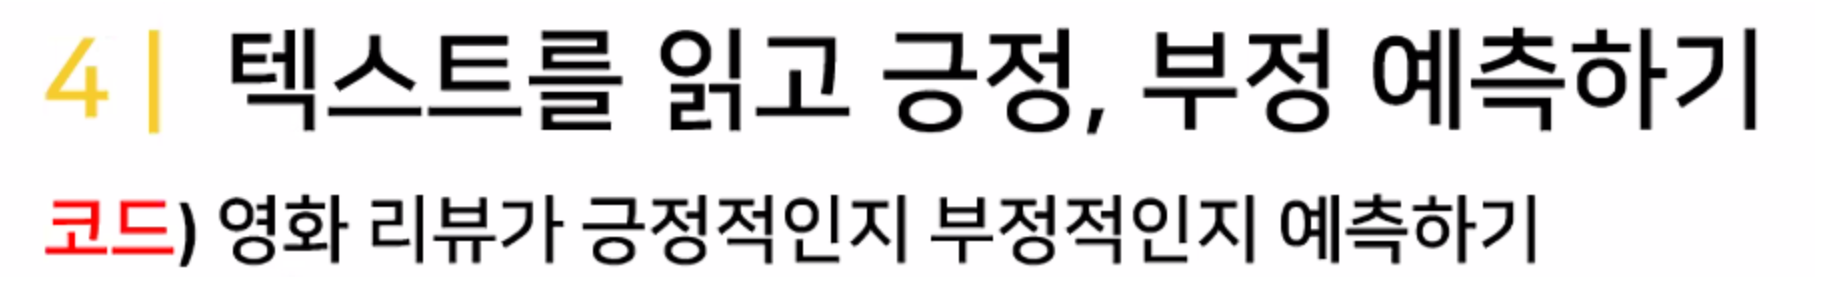

In [ ]:
import pickle

from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Embedding

# 텍스트 리뷰 자료를 지정합니다.
docs = ["너무 재밌네요","최고예요","참 잘 만든 영화예요","추천하고 싶은 영화입니다",
"한번 더 보고싶네요","글쎄요","별로예요","생각보다 지루하네요","연기가 어색해요","재미없어요"]

# 긍정 리뷰는 1, 부정 리뷰는 0으로 클래스 지정
classes = array([1,1,1,1,1,0,0,0,0,0])

# 토큰화
token = Tokenizer()
token.fit_on_texts(docs) # index : 1번부터 단어 배정, 0번은 비워둠
# print(token.word_index)

# 토크나이저 저장
with open('tokenizer.pickle', 'wb') as handle: # wb : 바이너리 쓰기 모드(없을 시 생성)
    pickle.dump(token, handle, protocol=pickle.HIGHEST_PROTOCOL) # pickle.dump() : tokenizer.pickle 파일에 token을 채워넣어라

x = token.texts_to_sequences(docs)
# print("토큰화 결과 :", x)

# 패딩 : 서로 다른 길이의 데이터를 4로 맞춘다
padded_x = pad_sequences(x, 4) # default : pre
# print("패딩 결과 :", padded_x)

# 모델
word_size = len(token.word_index) + 1

model = Sequential()
model.add(Embedding(word_size, 8, input_length=4))
#embedding_layer = Embedding(word_size, 8, input_length=4)
#model.add(embedding_layer)

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(padded_x, classes, epochs=20)
print("\n Accuracy : %.4f" % (model.evaluate(padded_x, classes)[1]))

model.save('sentiment_model.keras')

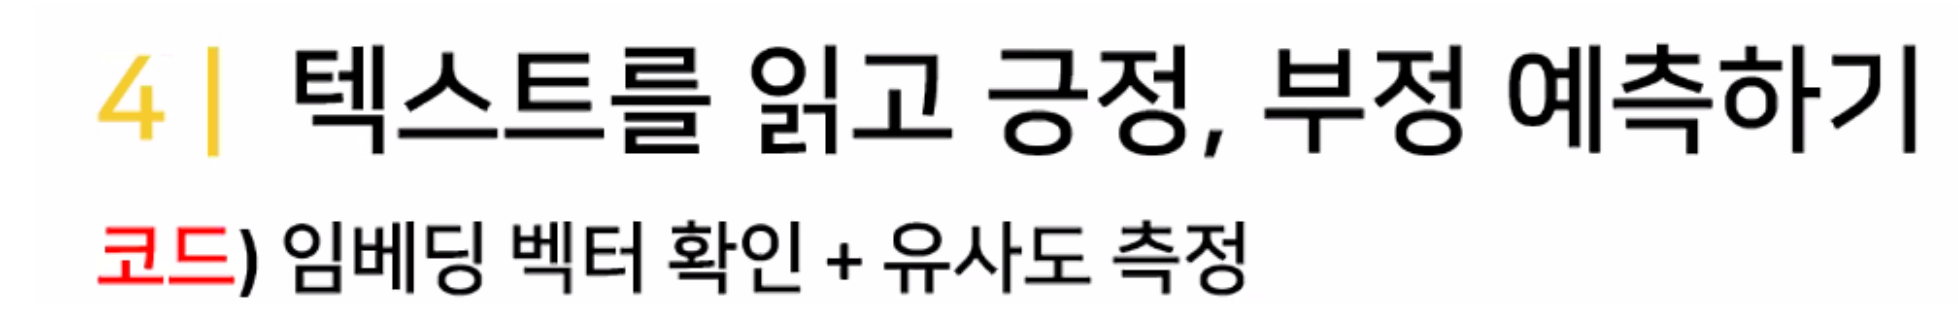

In [ ]:
import numpy as np
import pickle

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics.pairwise import cosine_similarity

with open('tokenizer.pickle', 'rb') as handle:
    token = pickle.load(handle)

model = load_model('sentiment_model.keras')

# layers[0] -> 가장 먼저 쌓은 Embedding layer
# get_weights()[0] -> 모든 가중치와 편향을 꺼낼 때, [(21, 8)] x -> (21, 8)로 꺼내기
embedding_matrix = model.layers[0].get_weights()[0] 
print("\n [단어 임베딩 행렬 shape] :", embedding_matrix.shape) # (단어 수, 벡터 차원)

# 단어별 벡터 확인
def print_word_vector(word):
    idx = token.word_index[word]
    print(f"단어 '{word}'의 임베딩 벡터:")
    print(embedding_matrix[idx])

# 유사도 계산 함수
def similarity(word1, word2):
    vec1 = embedding_matrix[token.word_index[word1]].reshape(1, -1)
    vec2 = embedding_matrix[token.word_index[word2]].reshape(1, -1)
    sim = cosine_similarity(vec1, vec2)[0][0]
    print(f"'{word1}' 과 '{word2}' 의 코사인 유사도 : {sim:.4f}")

# 단어 벡터 출력
print_word_vector("최고예요")
print_word_vector("지루하네요")

# 유사도 측정 예시
similarity("최고예요", "재밌네요")     # 긍정-긍정
similarity("지루하네요", "재미없어요") # 부정-부정
similarity("최고예요", "지루하네요")   # 긍정-부정

# 새로운 문장을 사용한 검증
new_reviews = ["참 재밌네요", "별로였어요", "잘 만든 영화입니다", "지루하네요 재미없어요"]
new_sequences = token.texts_to_sequences(new_reviews)
padded_new_sequences = pad_sequences(new_sequences, 4)

predictions = model.predict(padded_new_sequences)

# 예측 결과 출력
for review, prediction in zip(new_reviews, predictions):
    print(f"리뷰 : {review} -> 예측: {'긍정' if prediction > 0.5 else '부정'} (확률 : {prediction[0]:.4f})")     

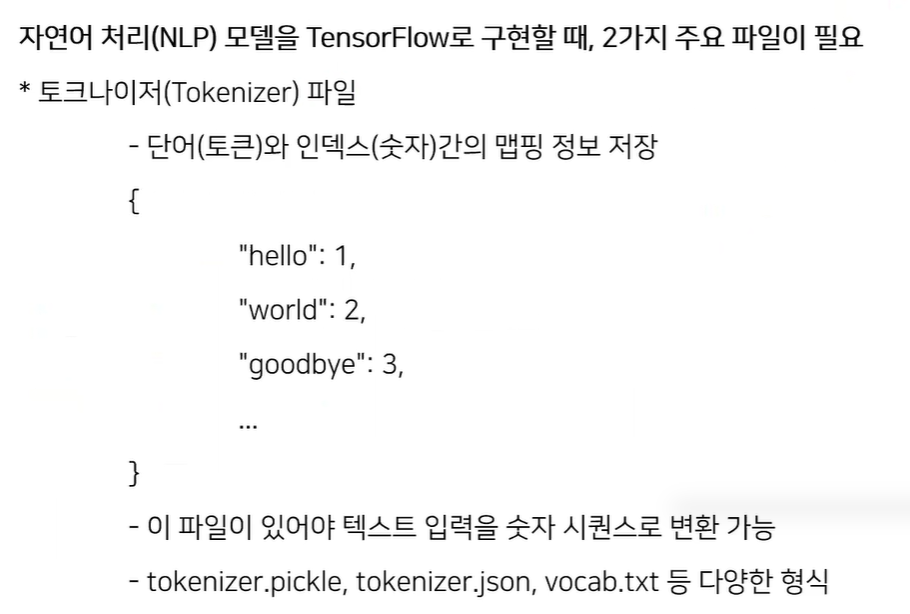

In [ ]:
# 토크나이저 파일, keras파일 2가지가 필요
# 토크나이저 : 단어(Token)과 숫자(Index)간의 매핑 정보 저장

# 토크나이저 저장 : 위에서 완료
with open('tokenizer.pickle', 'wb') as handle: # wb : 바이너리 쓰기 모드(없을 시 생성)
    pickle.dump(token, handle, protocol=pickle.HIGHEST_PROTOCOL) # pickle.dump() : tokenizer.pickle 파일에 token을 채워넣어라

# 모델 저장
model.save('sentiment_model.keras')

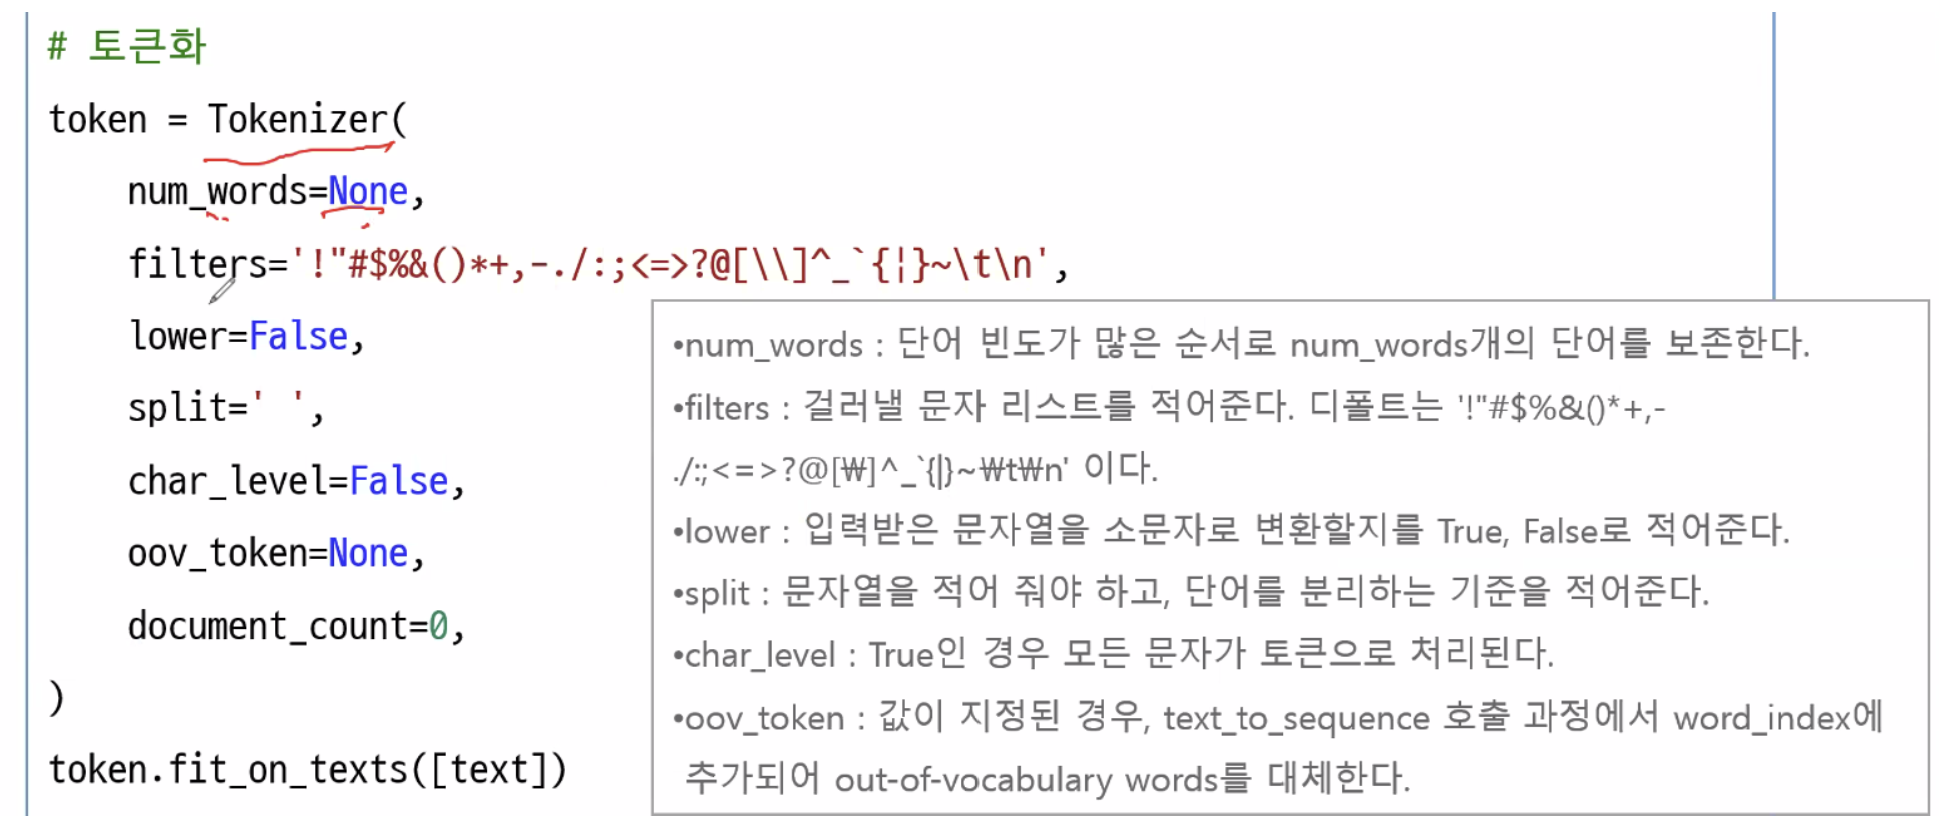

In [ ]:
import pickle

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# 토크나이저 로드
with open('tokenizer.pickle', 'rb') as handle:
    token = pickle.load(handle)

# 모델 로드
model = load_model('sentiment_model.keras')

# 새로운 문장을 사용한 검증
new_reviews = ["참 재밌네요", "별로였어요", "잘 만든 영화입니다", "지루하네요 재미없어요"]
new_sequences = token.texts_to_sequences(new_reviews)
# print(new_sequences)
padded_new_sequences = pad_sequences(new_sequences, 4)

# 예측
predictions = model.predict(padded_new_sequences)

# 예측 결과 출력
for review, prediction in zip(new_reviews, predictions) :
    print(f"리뷰 : {review} -> 예측 : {'긍정' if prediction > 0.5 else '부정'} (확률 : {prediction[0]:.4f})")

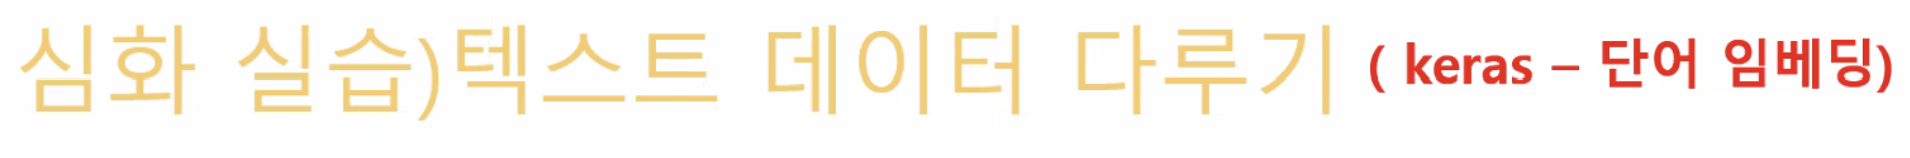

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras import preprocessing

# 리뷰에 사용되는 단어의 수를 10000개로 제한
# 가장 빈번한 max_features개의 단어만 사용한다
# Embdding(10000, 8, input_length)
max_features = 10000
# 사용할 텍스트의 길이
maxlen=20

# 정수 리스트로 데이터 로드
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print("학습 데이터 형태 :", x_train.shape, y_train.shape)
print("검증 데이터 형태 :", x_test.shape, y_test.shape)

# 리스트를 (samples, maxlen)크기의 2D정수 텐서로 변환한다
# 리뷰길이를 앞에 0을 붙여(pre), 20자 넘는경우 앞부분을 잘라내고(pre), 20자로 동일하게 만든다
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)
print(x_train[0])

In [ ]:
# x_train[0] 확인해보기

# IMDB 데이터셋의 단어 인덱스 로드
word_index = imdb.get_word_index()

# 딕셔너리
index_to_word = {index + 3: word for word, index in word_index.items()} # index + 3 : word, 즉 1(idx) : the(word) -> 4(idx) : the(word)
# imdb 특수문자 처리 규칙
index_to_word[0] = "<PAD>" # 패딩
index_to_word[1] = "<START>" # 시작
index_to_word[2] = "<UNK>" # unknown 단어
index_to_word[3] = "<UNUSED>" # unused 비워놓음, 나중에 기능 추가 등을 위해

# 숫자 시퀀스 -> 단어 시퀀스로
def decode_review(encoded_review):
    return ' '.join([index_to_word.get(i, '?') for i in encoded_review])

# 호출
decode_review = decode_review(x_train[0])
print("decode_review :", decode_review)

In [ ]:
# 모델 : 리뷰에 해당하는 긍정, 부정을 얼마나 잘 맞추었는지
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Embedding

model = Sequential()
model.add(Embedding(10000, 8, input_length=maxlen)) # 단어 1개를 8개의 실수로 표현
model.add(Flatten()) # 1차원으로 펼침
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

In [ ]:
# 임베딩 행렬 추출 : 단어의 의미와 관계 시각화
embedding_layer = model.layers[0]
embedding_matrix = embedding_layer.get_weights()[0] # [0]안붙이면 [] 씌워져 있음
# print(embedding_matrix.shape) # (10000, 8)
# print(embedding_matrix) # 1개의 단어 8개의 실수로 표현

word_index = imdb.get_word_index()

index_to_word = {i + 3: w for w, i in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

# 보고 싶은 단어의 임베딩 확인
def show_vector(word):
    idx = word_index.get(word)

    if idx is None or idx + 3 >= embedding_matrix.shape[0]: # shape : (10000, 8) -> shape[0] : 10000
        print("단어가 어휘 사전에 없습니다")
        return

    vec = embedding_matrix[idx + 3] # +3 오프셋
    print(f"'{word}' 임베딩:", vec)

show_vector("good")
show_vector("bad")
show_vector("movie")
show_vector("bomb")

In [ ]:
# 새로운 리뷰를 사용한 검증
new_reviews = [
    "It was a boring movie. I don't want to recommend it.",
    "The movie was extremely disappointing."
]

# 새로운 리뷰를 정수 인덱스로 변환
new_sequences = []
# word_index : 단어 사전
# get(word, 2) : 없으면 2번 <UNK>
for review in new_reviews:
    sequence = [word_index.get(word.lower(), 2) for word in review.replace('.', ' ').split()]
    new_sequences.append(sequence)

# 패딩
padded_new_sequences = preprocessing.sequence.pad_sequences(new_sequences, maxlen=maxlen)

# 예측
predictions = model.predict(padded_new_sequences)

# 예측 결과 출력
for review, prediction in zip(new_reviews, predictions):
    print(f"리뷰 : {review} -> 예측: {'긍정' if prediction > 0.5 else '부정'} (확률 : {prediction[0]:.4f})")

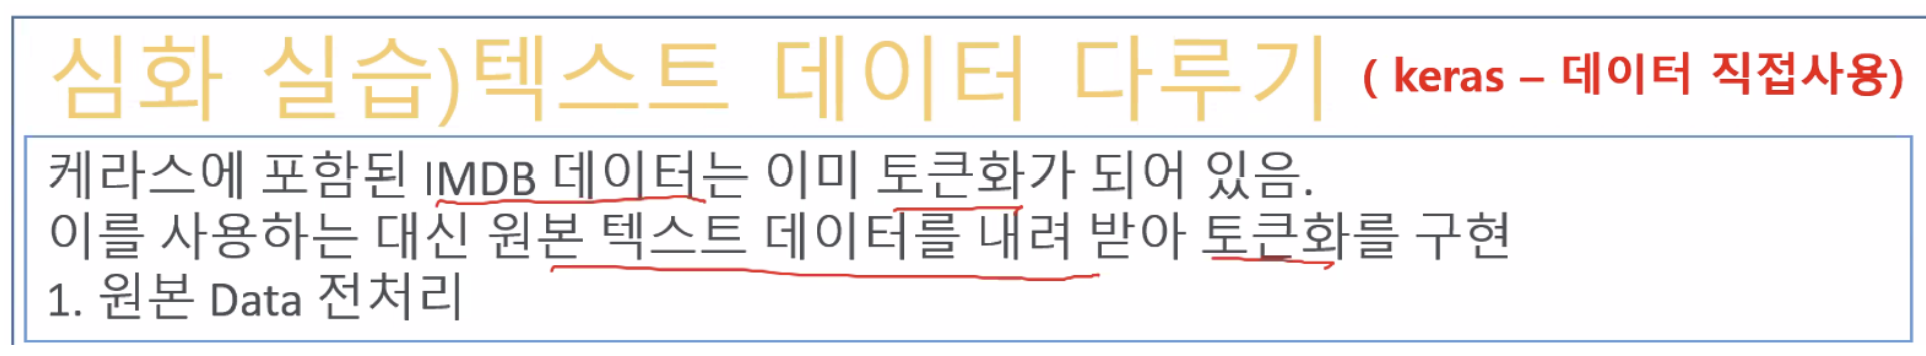

In [ ]:
## 단어장 없이, 영화 리뷰만을 가져와서 단어를 임의의 실수로 만들어 학습 후 
#  aclImdb 영화 리뷰를 긍정, 부정으로 분류

In [ ]:
import os
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#local OS인 경우
imdb_dir = './data_set/aclImdb/aclImdb'

#colab인 경우
#imdb_dir = '/content/drive/MyDrive/Colab Notebooks/dataset/aclImdb'

train_dir = os.path.join(imdb_dir, 'train')
labels = []
texts = []

#데이터 로드 및 라벨링
for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    # print(dir_name)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            with open(os.path.join(dir_name, fname), encoding='utf8') as f:
                texts.append(f.read())
            labels.append(0 if label_type == 'neg' else 1) # neg : 부정, pos : 긍정 

print(texts[0])       # 부정의 첫 번째 문장
print(labels[0])      # 부정의 첫 번째 label
print(texts[12500])   # 긍정의 첫 번째 문장
print(labels[12500])  # 긍정의 첫 번째 label

In [ ]:
# 데이터 전처리 설정
maxlen = 200 # 리뷰 길이
training_samples = 10000
validation_samples = 10000
max_words = 10000 # 데이터셋에서 가장 빈도 높은 10,000개의 단어 사용

# 토큰화
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('%s개의 고유한 단어가 단어사전에 등록되어 있습니다.' % len(word_index))

# 패딩
data = pad_sequences(sequences, maxlen=maxlen)
labels = np.asarray(labels) # ndarray로 변환
print('데이터 텐서의 크기 :', data.shape)
print('레이블 텐서의 크기 :', labels.shape)

# 데이터 셔플 : 0 ~ 12,499 -> 부정(0), 12,500 ~ 24,999 -> 긍정(1) 순으로 적재
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

# 데이터 분할
x_train = data[:training_samples]
y_train = labels[:training_samples]
x_val = data[training_samples : training_samples + validation_samples]
y_val = labels[training_samples : training_samples + validation_samples]

# 모델 정의
model = Sequential()
model.add(Embedding(max_words, 64, input_shape=(maxlen,)))
model.add(Bidirectional(LSTM(64, return_sequences=True))) # LSTM : 양방향
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

# 학습
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_val, y_val),
                    callbacks=[early_stopping, model_checkpoint])

In [ ]:
# 모델을 사용하여 예측
test_texts = [  # 아래 문장은 강의 채널에 올려 놓음
    "I hated this movie. It was terrible and the acting was horrible.",  # 부정
    "This was the worst film I have ever seen. Not worth the time.",  # 부정
    "I loved this movie. It was fantastic and the acting was great.",  # 긍정
    "This was the best film I have seen in a long time. Totally worth it.",  # 긍정
    "I had high hopes for this movie, but it was a complete letdown . . .",  # 부정
    "This film was a disaster from start to finish. The dialogue . . .",  # 부정
    "What an amazing film! The plot was deeply engaging, . . .",  # 긍정
    "I was thoroughly impressed by this film. . . . "  # 긍정
]
test_sequences = tokenizer.texts_to_sequences(test_texts)
test_data = pad_sequences(test_sequences, maxlen=maxlen)

# 모델 로드
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras', custom_objects=None, compile=True)

predictions = best_model.predict(test_data)

for i,test_text in enumerate(test_texts):
    print(f"Text {test_text[:20]}...")
    print(f"Prediction: {'Positive' if predictions[i] > 0.5 else 'Negative'} (확률 : {predictions[i][0]:.4f})")

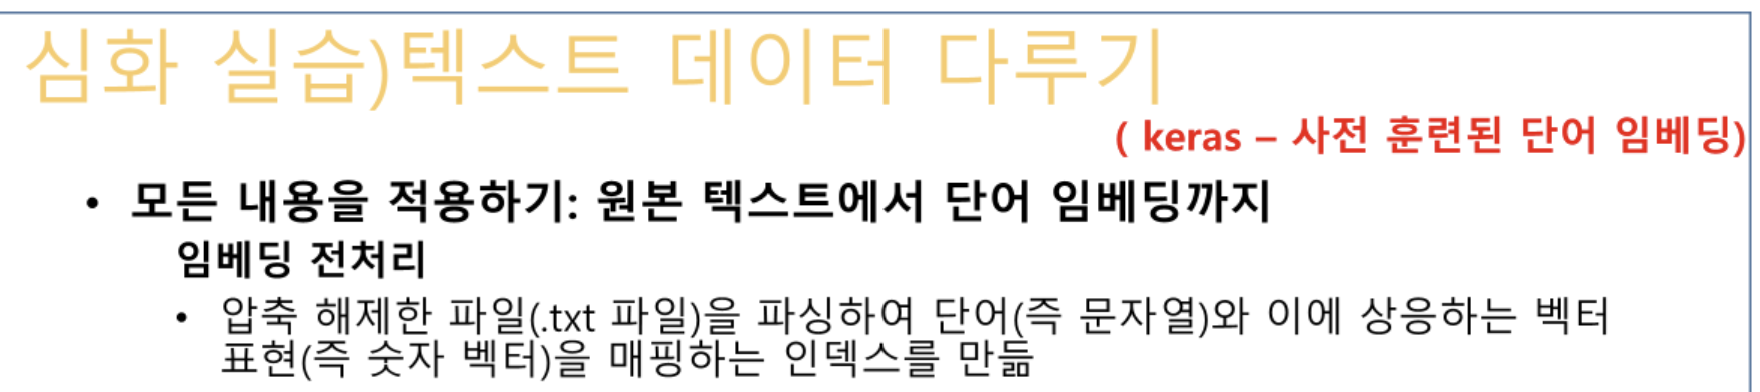

In [ ]:
##2 : GloVe 모델 사용 : 이미 학습된 단어장을 가져와서 IMDB 영화 리뷰를 긍정, 부정으로 분류

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer

#1. GloVe 임베딩 로드
glove_dir = './data_set/glove.6B'
embeddings_index = {}

# glove.6B.100d : 한 단어를 100개의 실수로 표현해놓은 텍스트 파일
# ['the', '0.418', '0.249', '-0.412', ...] 형태(맨 앞 : 단어)
with open(os.path.join(glove_dir, 'glove.6B.100d.txt'), encoding="utf8") as f:
    for line in f: # 한 줄 단위 처리
        values = line.split()
        word = values[0] # 단어(key)
        coefs = np.asarray(values[1:], dtype='float32') # 'the' 제외 나머지 문자열 형태 숫자 -> float32
        embeddings_index[word] = coefs
print("%s개의 단어 백터를 찾았습니다." % len(embeddings_index)) #400000

# 특정 단어의 임베딩 벡터 읽어오기
word = 'the'
embedding_vector = embeddings_index.get(word)
if embedding_vector is not None:
    print(f'{word} :', embedding_vector)
else:
    print(f'{word} is not find')

#2. IMDB 데이터셋 로드 및 전처리
max_words = 10000
maxlen = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

#3. IMDB 데이터셋 단어 인덱스를 GloVe 임베딩에 매핑
word_index = imdb.get_word_index()
embedding_dim = 100
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

#4. 모델 정의
model = Sequential()
model.add(Embedding(max_words, embedding_dim, weights=[embedding_matrix], input_length=maxlen, trainable=False))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

#5. 컴파일
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

#6. 학습
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test))

In [ ]:
#7. 시각화

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
#8. 모델을 사용해서 예측 
test_texts = [
    "I hated this movie. It was terrible and the acting was horrible.",
    "This was the worst film I have ever seen. Not worth the time.",
    "I loved this movie. It was fantastic and the acting was great.",
    "This was the best film I have seen in a long time. Totally worth it.",
    "I had high hopes for this movie, but it was a complete letdown. The storyline was incredibly dull, and the pacing was excruciatingly slow. The characters lacked depth, making it hard to care about their fates. Overall, a waste of time.",
    "This film was a disaster from start to finish. The dialogue was cringe-worthy, and the special effects looked outdated. I couldn't believe how poorly executed the entire production was. Definitely one to avoid.",
    "What an amazing film! The plot was deeply engaging, keeping me on the edge of my seat throughout. The actors delivered powerful performances that brought the story to life. This movie is a must-watch for everyone.",
    "I was thoroughly impressed by this film. The cinematography was stunning, capturing the beauty of every scene. The story was heartwarming and inspiring, and the music perfectly complemented the mood. An outstanding cinematic experience."
]

# 임베딩 행렬 추출
# 0번째 층이 Embedding 층
embedding_layer = model.layers[0]
embedding_matrix = embedding_layer.get_weights()[0]  # shape: (10000, 100)
print("임베딩 행렬 모양:", embedding_matrix.shape)  # (단어 수, 차원)

# 인덱스를 단어로 변환하는 딕셔너리 생성
index_to_word = {index + 3: word for word, index in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

new_tests = []
for tests in test_texts:
    sequence = []
    
    for word in tests.replace('.', '').replace('!', '').replace(',', '').split():
        idx = word_index.get(word.lower())

        if idx is not None and idx < max_words:
            sequence.append(idx)
        else:
            sequence.append(2)
    
    new_tests.append(sequence)

# 시퀀스를 패딩하여 동일한 길이로
padded_new_tests = pad_sequences(new_tests, maxlen=maxlen)
print("패딩 완료된 시퀀스 모양:", padded_new_tests.shape) # (8, 100)

# 새로운 리뷰에 대한 예측을 수행
predictions = model.predict(padded_new_tests)

# 결과
for i, text in enumerate(test_texts):
    print(f"Text: {text}")
    print(f"Predicted Sentiment: {'긍정' if predictions[i] > 0.5 else '부정'}")
    print(f"Prediction Score: {predictions[i][0]:.2f}")
    print()